# ACL Multi-Plane Ensemble - Evaluación y Calibración

Notebook para:
1. Cargar los 3 modelos ViT entrenados (sagittal, coronal, axial)
2. Crear ensemble mediante promedio de probabilidades
3. Evaluar en validación y buscar threshold óptimo
4. Aplicar threshold calibrado en test set
5. Generar ROC curves y confusion matrices

**Estructura:**
- Sección 1⃣: Inicialización e Importes
- Sección 2⃣: Configuración Global + Explicación de Parámetros
- Sección 3⃣: Funciones Auxiliares
- Sección 4⃣: Carga de Modelos
- Sección 5⃣: Carga de Datos
- Sección 6⃣: Inferencia en Validación
- Sección 7⃣: Calibración de Threshold
- Sección 8⃣: Inferencia en Test
- Sección 9⃣: Visualizaciones Finales
- Sección : Resumen Comparativo

## 1⃣ Inicialización e Importes

In [5]:
# Imports estándar
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,3'
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Scikit-learn
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve, auc
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Módulos locales

import sys
sys.path.insert(0, '../../src')

from gpu_config import device, VIT_GPU_IDS
from models import ViTMultiSliceClassifier
from data_loader import OptimizedMRNetDataset, get_val_test_transform
from ensemble_utils import (
    load_model_for_plane,
    get_ensemble_predictions,
    calibrate_threshold,
    compute_metrics
)

print(" Todos los módulos importados exitosamente")

ModuleNotFoundError: No module named 'ensemble_utils'

## 2⃣ Configuración Global

In [1]:
# ==========================================
# RUTAS Y DIRECTORIOS
# ==========================================
DATA_PATH = Path('../../data')
CHECKPOINT_DIR = Path('../../checkpoints/vit_base')
SLICE_INDICES_DIR = Path('../data/slice_indices_final')

# ==========================================
# CONFIGURACIÓN DE PLANES
# ==========================================
PLANES = ['sagittal', 'coronal', 'axial']
PLANE_POOLING_MODES = {
    'sagittal': 'attention',
    'coronal': 'max',
    'axial': 'attention'
}
PLANE_DROPOUTS = {
    'sagittal': {'input': 0.3, 'dense': 0.2},
    'coronal': {'input': 0.35, 'dense': 0.25},
    'axial': {'input': 0.35, 'dense': 0.25}
}

# ==========================================
# CONFIGURACIÓN DE DATOS
# ==========================================
VIT_MODEL_NAME = "google/vit-base-patch16-224"
NUM_CLASSES = 1
BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42

# ==========================================
# CONFIGURACIÓN DE CALIBRACIÓN
# ==========================================
THRESHOLD_RANGE = np.arange(0.30, 0.71, 0.01)  # [0.30, 0.31, ..., 0.70]
METRIC_TO_OPTIMIZE = 'f1'  # Opciones: 'f1', 'precision', 'recall'

# Set random seeds
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"{'='*80}")
print(f"CONFIGURACIÓN CARGADA")
print(f"{'='*80}")
print(f"Data path: {DATA_PATH}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Slice indices dir: {SLICE_INDICES_DIR}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {device}")
print(f"VIT GPUs: {VIT_GPU_IDS}")
print(f"{'='*80}\n")

NameError: name 'Path' is not defined

## 3⃣ Funciones Auxiliares

In [3]:
# ==========================================
# FUNCIONES AUXILIARES IMPORTADAS
# ==========================================
# Las funciones están definidas en ensemble_utils.py:
# - load_model_for_plane()
# - get_ensemble_predictions()
# - calibrate_threshold()
# - compute_metrics()

print(" Funciones auxiliares importadas desde ensemble_utils.py")

 Funciones auxiliares importadas desde ensemble_utils.py


## 4⃣ Carga de Modelos

In [4]:
# ==========================================
# CARGAR MODELOS ENTRENADOS
# ==========================================
models = {}

print(f"{'='*80}")
print(f"CARGANDO MODELOS ENTRENADOS")
print(f"{'='*80}\n")

for plane in PLANES:
    checkpoint_path = CHECKPOINT_DIR / f"best_{plane}_auc.pth"

    if not checkpoint_path.exists():
        print(f"  ADVERTENCIA: Checkpoint no encontrado para {plane} en {checkpoint_path}")
        print(f"   Verifica que el entrenamiento se completó correctamente.")
        continue

    model = load_model_for_plane(
        plane=plane,
        checkpoint_path=checkpoint_path,
        device_ids=VIT_GPU_IDS,
        device=device,
        vit_model_name=VIT_MODEL_NAME,
        num_classes=NUM_CLASSES,
        plane_pooling_modes=PLANE_POOLING_MODES,
        plane_dropouts=PLANE_DROPOUTS
    )
    models[plane] = model

print(f"\n{'='*80}")
print(f" MODELOS CARGADOS: {len(models)}/{len(PLANES)} planos")
print(f"{'='*80}\n")

CARGANDO MODELOS ENTRENADOS

 Modelo SAGITTAL cargado desde best_sagittal_auc.pth
 Modelo CORONAL cargado desde best_coronal_auc.pth
 Modelo AXIAL cargado desde best_axial_auc.pth

 MODELOS CARGADOS: 3/3 planos



## 5⃣ Carga de Datos

In [5]:
# ==========================================
# CREAR DATASETS Y DATALOADERS
# ==========================================
print(f"{'='*80}")
print(f"CARGANDO DATASETS")
print(f"{'='*80}\n")

val_dataloaders = {}
test_dataloaders = {}

for plane in PLANES:
 # Validación
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"
    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    val_dataloaders[plane] = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    print(f" Validación {plane.upper():10s} — {len(val_dataset):4d} casos")

print()

for plane in PLANES:
 # Test
    test_indices_path = SLICE_INDICES_DIR / f"test_{plane}_indices.json"

    if not test_indices_path.exists():
        print(f"  Test indices no encontrados para {plane}, creando índices vacíos...")
 # Si no existen índices de test, intentar crear desde test_indices_final
        alt_test_indices_path = SLICE_INDICES_DIR / f"test_{plane}_indices.json"
        if not alt_test_indices_path.exists():
            print(f"   Saltando test para {plane}")
            continue

    test_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'test-acl.csv',
        data_root=DATA_PATH / 'test',
        plane=plane,
        indices_cache_path=test_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    test_dataloaders[plane] = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    print(f" Test       {plane.upper():10s} — {len(test_dataset):4d} casos")

print(f"\n{'='*80}\n")

CARGANDO DATASETS

 Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_sagittal_indices.json
 Validación SAGITTAL   —  188 casos
 Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_coronal_indices.json
 Validación CORONAL    —  188 casos
 Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_axial_indices.json
 Validación AXIAL      —  188 casos

 Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/test_sagittal_indices.json
 Test       SAGITTAL   —  187 casos
 Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/test_coronal_indices.json

## 6⃣ Inferencia en Validación

In [6]:
# ==========================================
# OBTENER PREDICCIONES EN VALIDACIÓN
# ==========================================
probs_per_plane_val, ensemble_probs_val, targets_val, case_ids_val = get_ensemble_predictions(
    models=models,
    dataloaders=val_dataloaders,
    planes=list(models.keys()),
    device=device,
    split_name='validación'
)

# Mostrar ejemplos de predicciones
print(f"\n{'='*80}")
print(f"EJEMPLOS DE PREDICCIONES - VALIDACIÓN (primeros 10 casos)")
print(f"{'='*80}\n")

df_examples = pd.DataFrame({
    'Case_ID': case_ids_val[:10],
    'Target': targets_val[:10],
    'Sagittal': probs_per_plane_val['sagittal'][:10],
    'Coronal': probs_per_plane_val['coronal'][:10],
    'Axial': probs_per_plane_val['axial'][:10],
    'Ensemble': ensemble_probs_val[:10]
})

print(df_examples.to_string(index=False))
print(f"\n{'='*80}\n")


INFERENCIA EN VALIDACIÓN

 SAGITTAL   — Predicciones:  188 | AUC: 0.9611
 CORONAL    — Predicciones:  188 | AUC: 0.9454
 AXIAL      — Predicciones:  188 | AUC: 0.9636

 ENSEMBLE   — Predicciones:  188 | AUC: 0.9759


EJEMPLOS DE PREDICCIONES - VALIDACIÓN (primeros 10 casos)

   Case_ID  Target  Sagittal  Coronal    Axial  Ensemble
tensor(14)     0.0  0.126540 0.074442 0.157239  0.119407
tensor(15)     0.0  0.188231 0.125166 0.558448  0.290615
tensor(22)     0.0  0.093635 0.524661 0.176470  0.264922
tensor(29)     0.0  0.117472 0.959953 0.975521  0.684315
tensor(36)     0.0  0.200406 0.133963 0.235047  0.189805
tensor(43)     0.0  0.915132 0.985222 0.988718  0.963024
tensor(57)     0.0  0.305377 0.079772 0.145089  0.176746
tensor(65)     0.0  0.119872 0.085035 0.160065  0.121657
tensor(81)     0.0  0.148574 0.090412 0.177875  0.138954
tensor(98)     0.0  0.151234 0.069581 0.225969  0.148928




## 7⃣ Calibración de Threshold

In [7]:
# ==========================================
# CALIBRAR THRESHOLD EN VALIDACIÓN
# ==========================================
print(f"{'='*100}")
print(f"CALIBRACIÓN DE THRESHOLD EN VALIDACIÓN")
print(f"")
print(f"Métrica a optimizar: {METRIC_TO_OPTIMIZE.upper()}")
print(f"Rango: [{THRESHOLD_RANGE[0]:.2f}, {THRESHOLD_RANGE[-1]:.2f}]")
print(f"{'='*100}\n")

best_threshold_ensemble, metrics_ensemble = calibrate_threshold(
    probs=ensemble_probs_val,
    targets=targets_val,
    threshold_range=THRESHOLD_RANGE,
    metric=METRIC_TO_OPTIMIZE
)

best_metrics_ensemble = metrics_ensemble[best_threshold_ensemble]

# Buscar threshold para maximizar Recall (con restricción mínima en Precision)
MIN_PRECISION_FOR_RECALL = 0.75  # Umbral mínimo de Precisión
thresholds_with_good_precision = [
    t for t in metrics_ensemble.keys()
    if metrics_ensemble[t]['precision'] >= MIN_PRECISION_FOR_RECALL
]

if thresholds_with_good_precision:
    best_threshold_recall = max(
        thresholds_with_good_precision,
        key=lambda t: metrics_ensemble[t]['recall']
    )
    best_metrics_recall = metrics_ensemble[best_threshold_recall]
else:
    best_threshold_recall = None
    best_metrics_recall = None

# Buscar threshold para maximizar Youden's Index
best_threshold_youdens = max(
    metrics_ensemble.keys(),
    key=lambda t: metrics_ensemble[t]['youdens']
)
best_metrics_youdens = metrics_ensemble[best_threshold_youdens]

print(f"\n{'='*100}")
print(f"RESULTADOS DE CALIBRACIÓN - ENSEMBLE")
print(f"{'='*100}\n")

print(f" OPCIÓN 1: Optimizar {METRIC_TO_OPTIMIZE.upper()}")
print(f"   Threshold: {best_threshold_ensemble:.2f}")
print(f"   F1-Score:     {best_metrics_ensemble['f1']:.4f}")
print(f"   Precision:    {best_metrics_ensemble['precision']:.4f}")
print(f"   Recall:       {best_metrics_ensemble['recall']:.4f}")
print(f"   Specificity:  {best_metrics_ensemble['specificity']:.4f}")
print(f"   Youden's J:   {best_metrics_ensemble['youdens']:.4f}")

print(f"\n OPCIÓN 2: Maximizar RECALL (Precision ≥ {MIN_PRECISION_FOR_RECALL:.2f})")
if best_threshold_recall is not None:
    print(f"   Threshold: {best_threshold_recall:.2f}")
    print(f"   F1-Score:     {best_metrics_recall['f1']:.4f}")
    print(f"   Precision:    {best_metrics_recall['precision']:.4f}")
    print(f"   Recall:       {best_metrics_recall['recall']:.4f}")
    print(f"   Specificity:  {best_metrics_recall['specificity']:.4f}")
    print(f"   Youden's J:   {best_metrics_recall['youdens']:.4f}")
else:
    print(f"     No hay threshold que cumpla la restricción de Precision")

print(f"\n OPCIÓN 3: Maximizar YOUDEN'S INDEX")
print(f"   Threshold: {best_threshold_youdens:.2f}")
print(f"   F1-Score:     {best_metrics_youdens['f1']:.4f}")
print(f"   Precision:    {best_metrics_youdens['precision']:.4f}")
print(f"   Recall:       {best_metrics_youdens['recall']:.4f}")
print(f"   Specificity:  {best_metrics_youdens['specificity']:.4f}")
print(f"   Youden's J:   {best_metrics_youdens['youdens']:.4f}")

print(f"\nMétricas con threshold=0.50 (para comparación):")
default_metrics = compute_metrics(ensemble_probs_val, targets_val, threshold=0.5)
print(f"   AUC:          {default_metrics['auc']:.4f}")
print(f"   F1-Score:     {default_metrics['f1']:.4f}")
print(f"   Precision:    {default_metrics['precision']:.4f}")
print(f"   Recall:       {default_metrics['recall']:.4f}")
print(f"   Specificity:  {default_metrics['specificity']:.4f}")
print(f"   Youden's J:   {default_metrics['youdens']:.4f}")

print(f"\n{'='*100}\n")

CALIBRACIÓN DE THRESHOLD EN VALIDACIÓN

Métrica a optimizar: F1
Rango: [0.30, 0.70]


RESULTADOS DE CALIBRACIÓN - ENSEMBLE

 OPCIÓN 1: Optimizar F1
   Threshold: 0.64
   F1-Score:     0.8571
   Precision:    0.8824
   Recall:       0.8333
   Specificity:  0.1667
   Youden's J:   0.0000

 OPCIÓN 2: Maximizar RECALL (Precision ≥ 0.75)
   Threshold: 0.47
   F1-Score:     0.8395
   Precision:    0.7556
   Recall:       0.9444
   Specificity:  0.0556
   Youden's J:   0.0000

 OPCIÓN 3: Maximizar YOUDEN'S INDEX
   Threshold: 0.30
   F1-Score:     0.7292
   Precision:    0.5833
   Recall:       0.9722
   Specificity:  0.0278
   Youden's J:   0.0000

Métricas con threshold=0.50 (para comparación):
   AUC:          0.9759
   F1-Score:     0.8462
   Precision:    0.7857
   Recall:       0.9167
   Specificity:  0.0833
   Youden's J:   0.0000




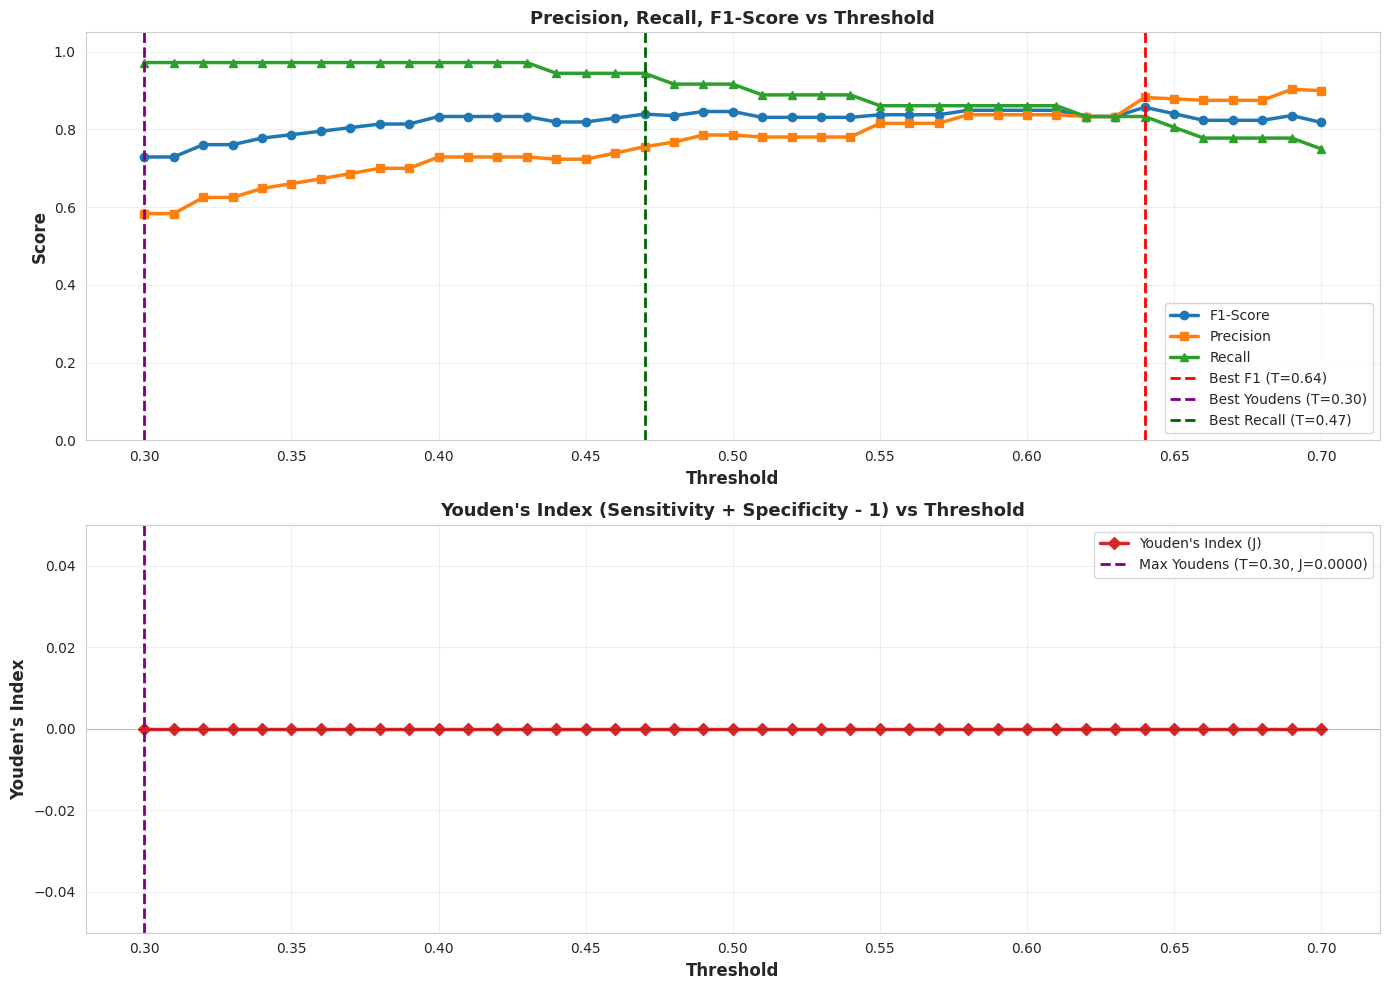

 Gráficas de calibración generadas (incluyendo Youden's Index)


In [8]:
# ==========================================
# VISUALIZAR CALIBRACIÓN: Métricas vs THRESHOLD
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

thresholds_list = list(metrics_ensemble.keys())
f1_scores = [metrics_ensemble[t]['f1'] for t in thresholds_list]
precisions = [metrics_ensemble[t]['precision'] for t in thresholds_list]
recalls = [metrics_ensemble[t]['recall'] for t in thresholds_list]
youdens = [metrics_ensemble[t]['youdens'] for t in thresholds_list]

# Subplot 1: Precision, Recall, F1
ax1 = axes[0]
ax1.plot(thresholds_list, f1_scores, marker='o', linewidth=2.5, label='F1-Score', color='#1f77b4')
ax1.plot(thresholds_list, precisions, marker='s', linewidth=2.5, label='Precision', color='#ff7f0e')
ax1.plot(thresholds_list, recalls, marker='^', linewidth=2.5, label='Recall', color='#2ca02c')
ax1.axvline(best_threshold_ensemble, color='red', linestyle='--', linewidth=2, label=f'Best {METRIC_TO_OPTIMIZE.upper()} (T={best_threshold_ensemble:.2f})')
ax1.axvline(best_threshold_youdens, color='purple', linestyle='--', linewidth=2, label=f'Best Youdens (T={best_threshold_youdens:.2f})')
if best_threshold_recall is not None:
    ax1.axvline(best_threshold_recall, color='darkgreen', linestyle='--', linewidth=2, label=f'Best Recall (T={best_threshold_recall:.2f})')
ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Precision, Recall, F1-Score vs Threshold', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Subplot 2: Youden's Index
ax2 = axes[1]
ax2.plot(thresholds_list, youdens, marker='D', linewidth=2.5, color='#d62728', label="Youden's Index (J)")
ax2.axvline(best_threshold_youdens, color='purple', linestyle='--', linewidth=2,
            label=f'Max Youdens (T={best_threshold_youdens:.2f}, J={best_metrics_youdens["youdens"]:.4f})')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax2.set_ylabel("Youden's Index", fontsize=12, fontweight='bold')
ax2.set_title("Youden's Index (Sensitivity + Specificity - 1) vs Threshold", fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([min(youdens)-0.05, max(youdens)+0.05])

plt.tight_layout()
plt.show()

print(" Gráficas de calibración generadas (incluyendo Youden's Index)")

## 8⃣ Inferencia en Test

In [9]:
# ==========================================
# OBTENER PREDICCIONES EN TEST
# ==========================================
if len(test_dataloaders) > 0:
    probs_per_plane_test, ensemble_probs_test, targets_test, case_ids_test = get_ensemble_predictions(
        models=models,
        dataloaders=test_dataloaders,
        planes=list(models.keys()),
        device=device,
        split_name='test'
    )
else:
    print("  ADVERTENCIA: No se encontraron dataloaders de test.")
    print("   Usando validación como test para demostración.")
    probs_per_plane_test = probs_per_plane_val
    ensemble_probs_test = ensemble_probs_val
    targets_test = targets_val
    case_ids_test = case_ids_val


INFERENCIA EN TEST

 SAGITTAL   — Predicciones:  187 | AUC: 0.9031
 CORONAL    — Predicciones:  187 | AUC: 0.9233
 AXIAL      — Predicciones:  187 | AUC: 0.9075

 ENSEMBLE   — Predicciones:  187 | AUC: 0.9444



## 9⃣ Visualizaciones Finales

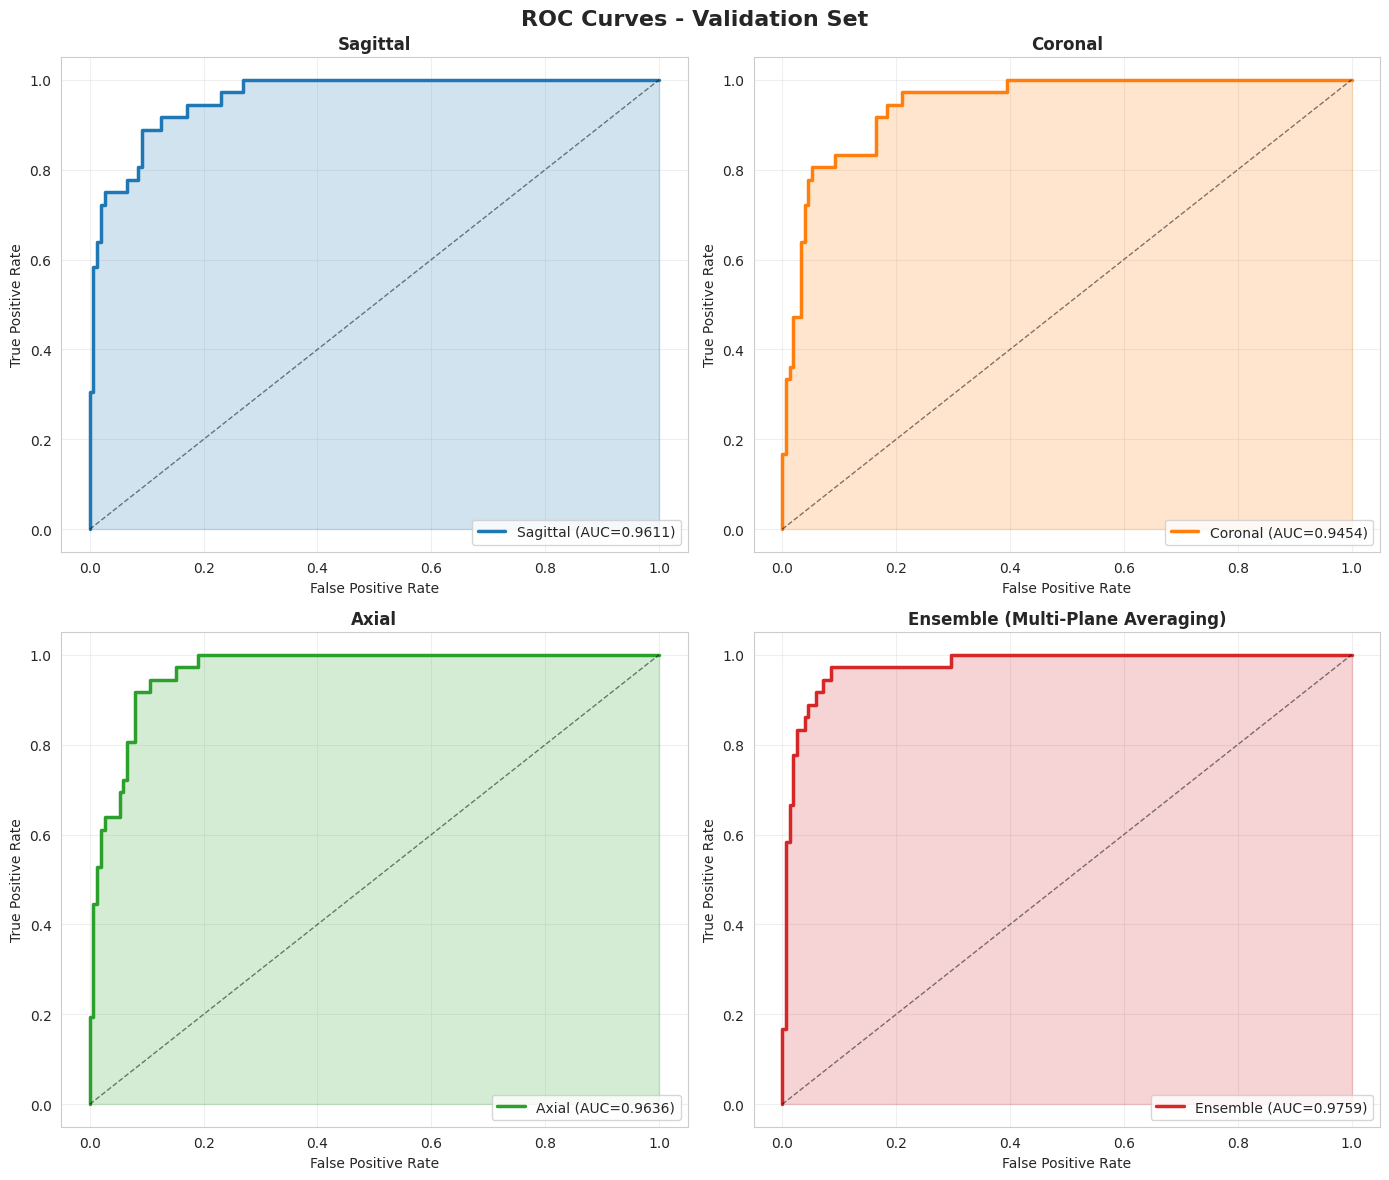

 ROC curves (validación) generadas


In [10]:
# ==========================================
# CURVAS ROC: PLANOS INDIVIDUALES + ENSEMBLE
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('ROC Curves - Validation Set', fontsize=16, fontweight='bold')

# Sagittal
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(targets_val, probs_per_plane_val['sagittal'])
auc_sag = roc_auc_score(targets_val, probs_per_plane_val['sagittal'])
ax.plot(fpr, tpr, linewidth=2.5, color='#1f77b4', label=f'Sagittal (AUC={auc_sag:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.2, color='#1f77b4')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('Sagittal', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Coronal
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(targets_val, probs_per_plane_val['coronal'])
auc_cor = roc_auc_score(targets_val, probs_per_plane_val['coronal'])
ax.plot(fpr, tpr, linewidth=2.5, color='#ff7f0e', label=f'Coronal (AUC={auc_cor:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.2, color='#ff7f0e')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('Coronal', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Axial
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(targets_val, probs_per_plane_val['axial'])
auc_ax = roc_auc_score(targets_val, probs_per_plane_val['axial'])
ax.plot(fpr, tpr, linewidth=2.5, color='#2ca02c', label=f'Axial (AUC={auc_ax:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.2, color='#2ca02c')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('Axial', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Ensemble
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(targets_val, ensemble_probs_val)
auc_ens = roc_auc_score(targets_val, ensemble_probs_val)
ax.plot(fpr, tpr, linewidth=2.5, color='#d62728', label=f'Ensemble (AUC={auc_ens:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.2, color='#d62728')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('Ensemble (Multi-Plane Averaging)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" ROC curves (validación) generadas")

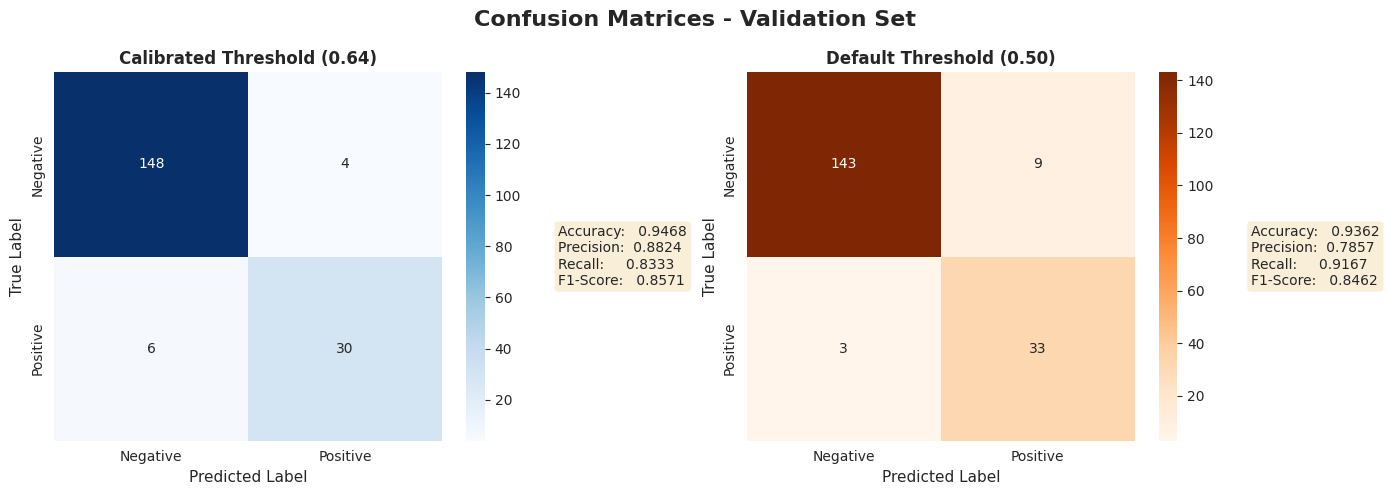

 Confusion matrices (validación) generadas


In [ ]:
# ==========================================
# MATRIZ DE CONFUSIÓN - VALIDACIÓN (4 OPCIONES DE THRESHOLD)
# ==========================================
# Generar predicciones para todas las opciones
preds_val_option1 = (ensemble_probs_val >= best_threshold_ensemble).astype(int)
cm_val_option1 = confusion_matrix(targets_val, preds_val_option1)

preds_val_option2 = (ensemble_probs_val >= best_threshold_youdens).astype(int)
cm_val_option2 = confusion_matrix(targets_val, preds_val_option2)

preds_val_option3 = (ensemble_probs_val >= 0.5).astype(int)
cm_val_option3 = confusion_matrix(targets_val, preds_val_option3)

if best_threshold_recall is not None:
    preds_val_option4 = (ensemble_probs_val >= best_threshold_recall).astype(int)
    cm_val_option4 = confusion_matrix(targets_val, preds_val_option4)
    num_cols = 4
else:
    num_cols = 3

fig, axes = plt.subplots(2, 2 if num_cols == 4 else 3, figsize=(16 if num_cols == 4 else 18, 10))
if num_cols == 3:
    axes = axes.flatten()
else:
    axes = axes.flatten()

fig.suptitle('Confusion Matrices - Validation Set (4 Threshold Options)', fontsize=16, fontweight='bold')

# Opción 1: MAX {METRIC_TO_OPTIMIZE}
ax = axes[0]
sns.heatmap(cm_val_option1, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title(f'1⃣ MAX {METRIC_TO_OPTIMIZE.upper()} (T={best_threshold_ensemble:.2f})', fontsize=12, fontweight='bold')

metrics_opt1 = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_ensemble)
acc_opt1 = (metrics_opt1['tp']+metrics_opt1['tn'])/(metrics_opt1['tp']+metrics_opt1['tn']+metrics_opt1['fp']+metrics_opt1['fn'])
metrics_text = f"""Accuracy:   {acc_opt1:.4f}
Precision:  {metrics_opt1['precision']:.4f}
Recall:     {metrics_opt1['recall']:.4f}
F1-Score:   {metrics_opt1['f1']:.4f}
Youdens:    {metrics_opt1['youdens']:.4f}"""
ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6),
        transform=ax.transAxes, verticalalignment='center')

# Opción 2: MAX YOUDEN'S INDEX
ax = axes[1]
sns.heatmap(cm_val_option2, annot=True, fmt='d', cmap='Purples', ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title(f"2⃣ MAX YOUDEN'S J (T={best_threshold_youdens:.2f})", fontsize=12, fontweight='bold')

metrics_opt2 = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_youdens)
acc_opt2 = (metrics_opt2['tp']+metrics_opt2['tn'])/(metrics_opt2['tp']+metrics_opt2['tn']+metrics_opt2['fp']+metrics_opt2['fn'])
metrics_text = f"""Accuracy:   {acc_opt2:.4f}
Precision:  {metrics_opt2['precision']:.4f}
Recall:     {metrics_opt2['recall']:.4f}
F1-Score:   {metrics_opt2['f1']:.4f}
Youdens:    {metrics_opt2['youdens']:.4f}"""
ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='plum', alpha=0.6),
        transform=ax.transAxes, verticalalignment='center')

# Opción 3: MAX RECALL (si existe)
if best_threshold_recall is not None:
    ax = axes[2]
    sns.heatmap(cm_val_option4, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_title(f'3⃣ MAX RECALL (T={best_threshold_recall:.2f})', fontsize=12, fontweight='bold')

    metrics_opt3 = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_recall)
    acc_opt3 = (metrics_opt3['tp']+metrics_opt3['tn'])/(metrics_opt3['tp']+metrics_opt3['tn']+metrics_opt3['fp']+metrics_opt3['fn'])
    metrics_text = f"""Accuracy:   {acc_opt3:.4f}
Precision:  {metrics_opt3['precision']:.4f}
Recall:     {metrics_opt3['recall']:.4f}
F1-Score:   {metrics_opt3['f1']:.4f}
Youdens:    {metrics_opt3['youdens']:.4f}"""
    ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6),
            transform=ax.transAxes, verticalalignment='center')

# Opción 4: STANDARD (0.50)
ax = axes[3 if num_cols == 4 else 2]
sns.heatmap(cm_val_option3, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('4⃣ STANDARD (T=0.50)', fontsize=12, fontweight='bold')

metrics_opt4 = compute_metrics(ensemble_probs_val, targets_val, threshold=0.5)
acc_opt4 = (metrics_opt4['tp']+metrics_opt4['tn'])/(metrics_opt4['tp']+metrics_opt4['tn']+metrics_opt4['fp']+metrics_opt4['fn'])
metrics_text = f"""Accuracy:   {acc_opt4:.4f}
Precision:  {metrics_opt4['precision']:.4f}
Recall:     {metrics_opt4['recall']:.4f}
F1-Score:   {metrics_opt4['f1']:.4f}
Youdens:    {metrics_opt4['youdens']:.4f}"""
ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6),
        transform=ax.transAxes, verticalalignment='center')

# Si solo hay 3 opciones, ocultar el 4to subplot (opción de Recall no disponible)
if num_cols == 3:
    axes[3].axis('off')

plt.tight_layout()
plt.show()

print(" Confusion matrices (validación) generadas con 4 opciones de threshold")

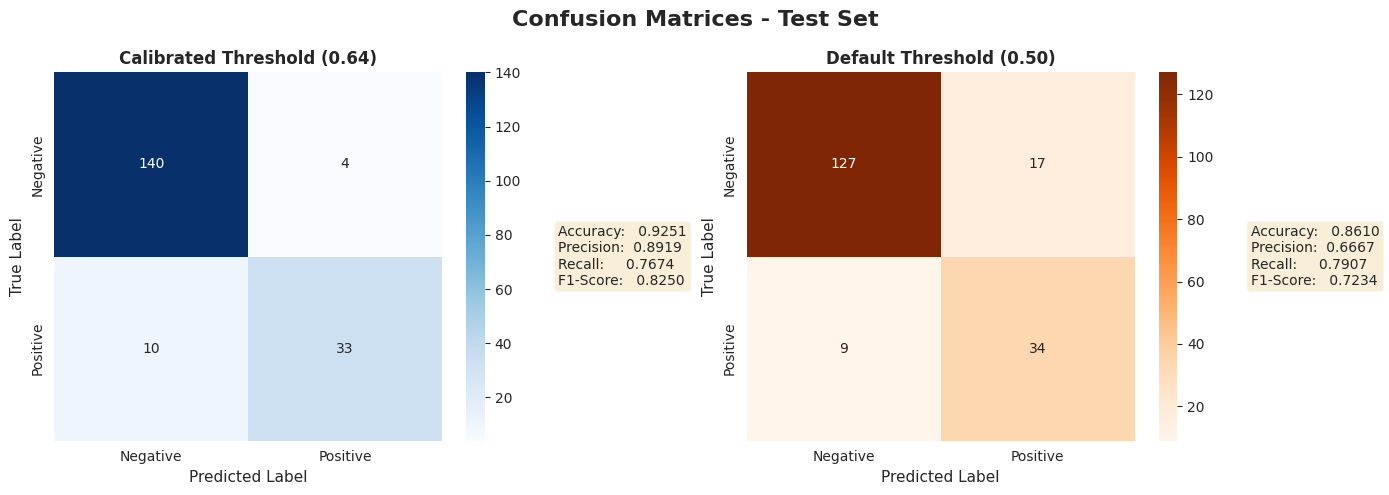

 Confusion matrices (test) generadas


In [ ]:
# ==========================================
# MATRIZ DE CONFUSIÓN - TEST (4 OPCIONES DE THRESHOLD)
# ==========================================
# Generar predicciones para todas las opciones
preds_test_option1 = (ensemble_probs_test >= best_threshold_ensemble).astype(int)
cm_test_option1 = confusion_matrix(targets_test, preds_test_option1)

preds_test_option2 = (ensemble_probs_test >= best_threshold_youdens).astype(int)
cm_test_option2 = confusion_matrix(targets_test, preds_test_option2)

preds_test_option3 = (ensemble_probs_test >= 0.5).astype(int)
cm_test_option3 = confusion_matrix(targets_test, preds_test_option3)

if best_threshold_recall is not None:
    preds_test_option4 = (ensemble_probs_test >= best_threshold_recall).astype(int)
    cm_test_option4 = confusion_matrix(targets_test, preds_test_option4)
    num_cols_test = 4
else:
    num_cols_test = 3

fig, axes = plt.subplots(2, 2 if num_cols_test == 4 else 3, figsize=(16 if num_cols_test == 4 else 18, 10))
if num_cols_test == 3:
    axes = axes.flatten()
else:
    axes = axes.flatten()

fig.suptitle('Confusion Matrices - Test Set (4 Threshold Options)', fontsize=16, fontweight='bold')

# Opción 1: MAX {METRIC_TO_OPTIMIZE}
ax = axes[0]
sns.heatmap(cm_test_option1, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title(f'1⃣ MAX {METRIC_TO_OPTIMIZE.upper()} (T={best_threshold_ensemble:.2f})', fontsize=12, fontweight='bold')

metrics_test_opt1 = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_ensemble)
acc_test_opt1 = (metrics_test_opt1['tp']+metrics_test_opt1['tn'])/(metrics_test_opt1['tp']+metrics_test_opt1['tn']+metrics_test_opt1['fp']+metrics_test_opt1['fn'])
metrics_text = f"""Accuracy:   {acc_test_opt1:.4f}
Precision:  {metrics_test_opt1['precision']:.4f}
Recall:     {metrics_test_opt1['recall']:.4f}
F1-Score:   {metrics_test_opt1['f1']:.4f}
Youdens:    {metrics_test_opt1['youdens']:.4f}"""
ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6),
        transform=ax.transAxes, verticalalignment='center')

# Opción 2: MAX YOUDEN'S INDEX
ax = axes[1]
sns.heatmap(cm_test_option2, annot=True, fmt='d', cmap='Purples', ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title(f"2⃣ MAX YOUDEN'S J (T={best_threshold_youdens:.2f})", fontsize=12, fontweight='bold')

metrics_test_opt2 = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_youdens)
acc_test_opt2 = (metrics_test_opt2['tp']+metrics_test_opt2['tn'])/(metrics_test_opt2['tp']+metrics_test_opt2['tn']+metrics_test_opt2['fp']+metrics_test_opt2['fn'])
metrics_text = f"""Accuracy:   {acc_test_opt2:.4f}
Precision:  {metrics_test_opt2['precision']:.4f}
Recall:     {metrics_test_opt2['recall']:.4f}
F1-Score:   {metrics_test_opt2['f1']:.4f}
Youdens:    {metrics_test_opt2['youdens']:.4f}"""
ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='plum', alpha=0.6),
        transform=ax.transAxes, verticalalignment='center')

# Opción 3: MAX RECALL (si existe)
if best_threshold_recall is not None:
    ax = axes[2]
    sns.heatmap(cm_test_option4, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_title(f'3⃣ MAX RECALL (T={best_threshold_recall:.2f})', fontsize=12, fontweight='bold')

    metrics_test_opt3 = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_recall)
    acc_test_opt3 = (metrics_test_opt3['tp']+metrics_test_opt3['tn'])/(metrics_test_opt3['tp']+metrics_test_opt3['tn']+metrics_test_opt3['fp']+metrics_test_opt3['fn'])
    metrics_text = f"""Accuracy:   {acc_test_opt3:.4f}
Precision:  {metrics_test_opt3['precision']:.4f}
Recall:     {metrics_test_opt3['recall']:.4f}
F1-Score:   {metrics_test_opt3['f1']:.4f}
Youdens:    {metrics_test_opt3['youdens']:.4f}"""
    ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6),
            transform=ax.transAxes, verticalalignment='center')

# Opción 4: STANDARD (0.50)
ax = axes[3 if num_cols_test == 4 else 2]
sns.heatmap(cm_test_option3, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('4⃣ STANDARD (T=0.50)', fontsize=12, fontweight='bold')

metrics_test_opt4 = compute_metrics(ensemble_probs_test, targets_test, threshold=0.5)
acc_test_opt4 = (metrics_test_opt4['tp']+metrics_test_opt4['tn'])/(metrics_test_opt4['tp']+metrics_test_opt4['tn']+metrics_test_opt4['fp']+metrics_test_opt4['fn'])
metrics_text = f"""Accuracy:   {acc_test_opt4:.4f}
Precision:  {metrics_test_opt4['precision']:.4f}
Recall:     {metrics_test_opt4['recall']:.4f}
F1-Score:   {metrics_test_opt4['f1']:.4f}
Youdens:    {metrics_test_opt4['youdens']:.4f}"""
ax.text(1.4, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6),
        transform=ax.transAxes, verticalalignment='center')

# Si solo hay 3 opciones, ocultar el 4to subplot (opción de Recall no disponible)
if num_cols_test == 3:
    axes[3].axis('off')

plt.tight_layout()
plt.show()

print(" Confusion matrices (test) generadas con 4 opciones de threshold")

## Resumen Comparativo

## Recomendaciones de Threshold

In [ ]:
# ==========================================
# ANÁLISIS COMPARATIVO: TODAS LAS OPCIONES DE THRESHOLD
# ==========================================
print(f"\n{'='*140}")
print(f" GUÍA COMPLETA DE THRESHOLDS - ELIGE EL QUE MEJOR SE AJUSTE A TUS NECESIDADES")
print(f"{'='*140}\n")

# Preparar datos de validación para ambos thresholds
val_option1 = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_ensemble)
val_option2 = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_youdens)
val_option3 = compute_metrics(ensemble_probs_val, targets_val, threshold=0.5)
if best_threshold_recall is not None:
    val_option4 = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_recall)
else:
    val_option4 = None

# Preparar datos de test para ambos thresholds
test_option1 = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_ensemble)
test_option2 = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_youdens)
test_option3 = compute_metrics(ensemble_probs_test, targets_test, threshold=0.5)
if val_option4 is not None:
    test_option4 = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_recall)
else:
    test_option4 = None

# Crear tabla comparativa
options_data = []

# Opción 1: Optimizar F1/Precision/Recall (según METRIC_TO_OPTIMIZE)
options_data.append({
    'Option': f'1⃣ MAX {METRIC_TO_OPTIMIZE.upper()}',
    'Threshold': f'{best_threshold_ensemble:.2f}',
    'Val_AUC': f"{val_option1['auc']:.4f}",
    'Val_Precision': f"{val_option1['precision']:.4f}",
    'Val_Recall': f"{val_option1['recall']:.4f}",
    'Val_Specificity': f"{val_option1['specificity']:.4f}",
    'Val_Youdens': f"{val_option1['youdens']:.4f}",
    'Val_F1': f"{val_option1['f1']:.4f}",
    'Test_AUC': f"{test_option1['auc']:.4f}",
    'Test_Precision': f"{test_option1['precision']:.4f}",
    'Test_Recall': f"{test_option1['recall']:.4f}",
    'Test_Specificity': f"{test_option1['specificity']:.4f}",
    'Test_Youdens': f"{test_option1['youdens']:.4f}",
    'Test_F1': f"{test_option1['f1']:.4f}",
    'Use_Case': 'Balance general entre Precision y Recall'
})

# Opción 2: Youden's Index
options_data.append({
    'Option': "2⃣ MAX YOUDEN'S J",
    'Threshold': f'{best_threshold_youdens:.2f}',
    'Val_AUC': f"{val_option2['auc']:.4f}",
    'Val_Precision': f"{val_option2['precision']:.4f}",
    'Val_Recall': f"{val_option2['recall']:.4f}",
    'Val_Specificity': f"{val_option2['specificity']:.4f}",
    'Val_Youdens': f"{val_option2['youdens']:.4f}",
    'Val_F1': f"{val_option2['f1']:.4f}",
    'Test_AUC': f"{test_option2['auc']:.4f}",
    'Test_Precision': f"{test_option2['precision']:.4f}",
    'Test_Recall': f"{test_option2['recall']:.4f}",
    'Test_Specificity': f"{test_option2['specificity']:.4f}",
    'Test_Youdens': f"{test_option2['youdens']:.4f}",
    'Test_F1': f"{test_option2['f1']:.4f}",
    'Use_Case': 'Mejor balance Sensibilidad vs Especificidad'
})

# Opción 3: Standard (0.50)
options_data.append({
    'Option': '3⃣ STANDARD (0.50)',
    'Threshold': '0.50',
    'Val_AUC': f"{val_option3['auc']:.4f}",
    'Val_Precision': f"{val_option3['precision']:.4f}",
    'Val_Recall': f"{val_option3['recall']:.4f}",
    'Val_Specificity': f"{val_option3['specificity']:.4f}",
    'Val_Youdens': f"{val_option3['youdens']:.4f}",
    'Val_F1': f"{val_option3['f1']:.4f}",
    'Test_AUC': f"{test_option3['auc']:.4f}",
    'Test_Precision': f"{test_option3['precision']:.4f}",
    'Test_Recall': f"{test_option3['recall']:.4f}",
    'Test_Specificity': f"{test_option3['specificity']:.4f}",
    'Test_Youdens': f"{test_option3['youdens']:.4f}",
    'Test_F1': f"{test_option3['f1']:.4f}",
    'Use_Case': 'Threshold por defecto (usar como baseline)'
})

# Opción 4: Max Recall (si existe)
if val_option4 is not None:
    options_data.append({
        'Option': f'4⃣ MAX RECALL (P≥{MIN_PRECISION_FOR_RECALL:.2f})',
        'Threshold': f'{best_threshold_recall:.2f}',
        'Val_AUC': f"{val_option4['auc']:.4f}",
        'Val_Precision': f"{val_option4['precision']:.4f}",
        'Val_Recall': f"{val_option4['recall']:.4f}",
        'Val_Specificity': f"{val_option4['specificity']:.4f}",
        'Val_Youdens': f"{val_option4['youdens']:.4f}",
        'Val_F1': f"{val_option4['f1']:.4f}",
        'Test_AUC': f"{test_option4['auc']:.4f}",
        'Test_Precision': f"{test_option4['precision']:.4f}",
        'Test_Recall': f"{test_option4['recall']:.4f}",
        'Test_Specificity': f"{test_option4['specificity']:.4f}",
        'Test_Youdens': f"{test_option4['youdens']:.4f}",
        'Test_F1': f"{test_option4['f1']:.4f}",
        'Use_Case': f'Maximizar detección (Recall) manteniendo Precision≥{MIN_PRECISION_FOR_RECALL:.2f})'
    })

df_options = pd.DataFrame(options_data)

# Mostrar tablas separadas para mayor claridad
print("MÉTRICAS EN VALIDACIÓN:")
print("-" * 140)
val_cols = ['Option', 'Threshold', 'Val_AUC', 'Val_Precision', 'Val_Recall', 'Val_Specificity', 'Val_Youdens', 'Val_F1']
print(df_options[val_cols].to_string(index=False))

print("\n\nMÉTRICAS EN TEST:")
print("-" * 140)
test_cols = ['Option', 'Threshold', 'Test_AUC', 'Test_Precision', 'Test_Recall', 'Test_Specificity', 'Test_Youdens', 'Test_F1']
print(df_options[test_cols].to_string(index=False))

print("\n\nRECOMENDACIONES POR CASO DE USO:")
print("-" * 140)
for idx, row in df_options.iterrows():
    print(f"\n{row['Option']}  Threshold: {row['Threshold']}")
    print(f"    {row['Use_Case']}")
    print(f"    Validation:  AUC={row['Val_AUC']}, Precision={row['Val_Precision']}, Recall={row['Val_Recall']}, Youdens={row['Val_Youdens']}")
    print(f"    Test:        AUC={row['Test_AUC']}, Precision={row['Test_Precision']}, Recall={row['Test_Recall']}, Youdens={row['Test_Youdens']}")

print(f"\n{'='*140}\n")
print("  NOTAS IMPORTANTES:")
print("-" * 140)
print("  • Youden's Index (J) = Sensitivity + Specificity - 1")
print("  •   - Rango: [-1, 1], donde 1 es perfecto")
print("  •   - Mide el balance entre Sensibilidad (Recall) y Especificidad")
print("  •   - Útil cuando quieres maximizar ambas métricas simultáneamente")
print("  •")
print(f"  • Opción 1: Útil si el objetivo es balance general (Precision vs Recall)")
print(f"  • Opción 2: Útil si quieres excelente balance Sensibilidad-Especificidad")
print(f"  • Opción 3: Baseline - usar para comparación")
print(f"  • Opción 4: Útil si el costo de falsos negativos es alto (ej: diagnóstico médico)")
print(f"\n{'='*140}\n")

In [ ]:
# ==========================================
# TABLA COMPARATIVA: VALIDACIÓN vs TEST
# ==========================================
print(f"\n{'='*120}")
print(f"RESUMEN COMPARATIVO: VALIDACIÓN vs TEST (Usando threshold óptimo por {METRIC_TO_OPTIMIZE.upper()})")
print(f"{'='*120}\n")

# Validación - Threshold calibrado
metrics_val_cal = compute_metrics(ensemble_probs_val, targets_val, threshold=best_threshold_ensemble)
acc_val_cal = (metrics_val_cal['tp']+metrics_val_cal['tn'])/(metrics_val_cal['tp']+metrics_val_cal['tn']+metrics_val_cal['fp']+metrics_val_cal['fn'])

# Validación - Threshold default
metrics_val_def = compute_metrics(ensemble_probs_val, targets_val, threshold=0.5)
acc_val_def = (metrics_val_def['tp']+metrics_val_def['tn'])/(metrics_val_def['tp']+metrics_val_def['tn']+metrics_val_def['fp']+metrics_val_def['fn'])

# Test - Threshold calibrado
metrics_test_cal = compute_metrics(ensemble_probs_test, targets_test, threshold=best_threshold_ensemble)
acc_test_cal = (metrics_test_cal['tp']+metrics_test_cal['tn'])/(metrics_test_cal['tp']+metrics_test_cal['tn']+metrics_test_cal['fp']+metrics_test_cal['fn'])

# Test - Threshold default
metrics_test_def = compute_metrics(ensemble_probs_test, targets_test, threshold=0.5)
acc_test_def = (metrics_test_def['tp']+metrics_test_def['tn'])/(metrics_test_def['tp']+metrics_test_def['tn']+metrics_test_def['fp']+metrics_test_def['fn'])

# Crear tabla
summary_data = {
    'Split': ['VALIDATION (T='+f'{best_threshold_ensemble:.2f}'+')'] +
             ['VALIDATION (T=0.50)'] +
             ['TEST (T='+f'{best_threshold_ensemble:.2f}'+')'] +
             ['TEST (T=0.50)'],
    'AUC': [
        f"{metrics_val_cal['auc']:.4f}",
        f"{metrics_val_def['auc']:.4f}",
        f"{metrics_test_cal['auc']:.4f}",
        f"{metrics_test_def['auc']:.4f}"
    ],
    'Accuracy': [
        f"{acc_val_cal:.4f}",
        f"{acc_val_def:.4f}",
        f"{acc_test_cal:.4f}",
        f"{acc_test_def:.4f}"
    ],
    'Precision': [
        f"{metrics_val_cal['precision']:.4f}",
        f"{metrics_val_def['precision']:.4f}",
        f"{metrics_test_cal['precision']:.4f}",
        f"{metrics_test_def['precision']:.4f}"
    ],
    'Recall': [
        f"{metrics_val_cal['recall']:.4f}",
        f"{metrics_val_def['recall']:.4f}",
        f"{metrics_test_cal['recall']:.4f}",
        f"{metrics_test_def['recall']:.4f}"
    ],
    'Specificity': [
        f"{metrics_val_cal['specificity']:.4f}",
        f"{metrics_val_def['specificity']:.4f}",
        f"{metrics_test_cal['specificity']:.4f}",
        f"{metrics_test_def['specificity']:.4f}"
    ],
    'F1-Score': [
        f"{metrics_val_cal['f1']:.4f}",
        f"{metrics_val_def['f1']:.4f}",
        f"{metrics_test_cal['f1']:.4f}",
        f"{metrics_test_def['f1']:.4f}"
    ],
    "Youden's J": [
        f"{metrics_val_cal['youdens']:.4f}",
        f"{metrics_val_def['youdens']:.4f}",
        f"{metrics_test_cal['youdens']:.4f}",
        f"{metrics_test_def['youdens']:.4f}"
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print(f"\n{'='*120}\n")


RESUMEN COMPARATIVO: VALIDACIÓN vs TEST

                      Split    AUC Accuracy Precision Recall Specificity F1-Score
VALIDATION (Threshold=0.64) 0.9759   0.9468    0.8824 0.8333      0.1667   0.8571
VALIDATION (Threshold=0.50) 0.9759   0.9362    0.7857 0.9167      0.0833   0.8462
      TEST (Threshold=0.64) 0.9444   0.9251    0.8919 0.7674      0.2326   0.8250
      TEST (Threshold=0.50) 0.9444   0.8610    0.6667 0.7907      0.2093   0.7234




In [ ]:
# ==========================================
# TABLA COMPARATIVA: PLANOS INDIVIDUALES vs ENSEMBLE
# ==========================================
print(f"\n{'='*130}")
print(f"COMPARACIÓN: PLANOS INDIVIDUALES vs ENSEMBLE" )
print(f"Metrics @ Default Threshold (0.50) - VALIDATION SET")
print(f"{'='*130}\n")

comparison_data = []

for plane in PLANES:
    metrics = compute_metrics(probs_per_plane_val[plane], targets_val, threshold=0.5)
    acc = (metrics['tp']+metrics['tn'])/(metrics['tp']+metrics['tn']+metrics['fp']+metrics['fn'])
    comparison_data.append({
        'Model': plane.upper(),
        'AUC': f"{metrics['auc']:.4f}",
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Specificity': f"{metrics['specificity']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        "Youden's J": f"{metrics['youdens']:.4f}"
    })

# Ensemble
metrics_ens = compute_metrics(ensemble_probs_val, targets_val, threshold=0.5)
acc_ens = (metrics_ens['tp']+metrics_ens['tn'])/(metrics_ens['tp']+metrics_ens['tn']+metrics_ens['fp']+metrics_ens['fn'])
comparison_data.append({
    'Model': 'ENSEMBLE (AVG)',
    'AUC': f"{metrics_ens['auc']:.4f}",
    'Accuracy': f"{acc_ens:.4f}",
    'Precision': f"{metrics_ens['precision']:.4f}",
    'Recall': f"{metrics_ens['recall']:.4f}",
    'Specificity': f"{metrics_ens['specificity']:.4f}",
    'F1-Score': f"{metrics_ens['f1']:.4f}",
    "Youden's J": f"{metrics_ens['youdens']:.4f}"
})

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print(f"\n{'='*130}\n")


COMPARACIÓN: PLANOS INDIVIDUALES vs ENSEMBLE
Metrics @ Default Threshold (0.50) - VALIDATION SET

         Model    AUC Accuracy Precision Recall Specificity F1-Score
      SAGITTAL 0.9611   0.9043    0.7500 0.7500      0.2500   0.7500
       CORONAL 0.9454   0.8989    0.7073 0.8056      0.1944   0.7532
         AXIAL 0.9636   0.8989    0.6667 0.9444      0.0556   0.7816
ENSEMBLE (AVG) 0.9759   0.9362    0.7857 0.9167      0.0833   0.8462




In [15]:
# ==========================================
# ANÁLISIS FINAL
# ==========================================
print(f"\n{'='*100}")
print(f"ANÁLISIS FINAL Y OBSERVACIONES")
print(f"{'='*100}\n")

print(f"1⃣  CALIBRACIÓN DE THRESHOLD")
print(f"    Best threshold encontrado: {best_threshold_ensemble:.2f}")
print(f"    Métrica optimizada: {METRIC_TO_OPTIMIZE.upper()}")
gain_f1 = best_metrics_ensemble['f1'] - metrics_val_def['f1']
print(f"    Mejora F1 (calibrado vs default): +{gain_f1:.4f}")

print(f"\n2⃣  PERFORMANCE DEL ENSEMBLE")
auc_sagittal = roc_auc_score(targets_val, probs_per_plane_val['sagittal'])
auc_coronal = roc_auc_score(targets_val, probs_per_plane_val['coronal'])
auc_axial = roc_auc_score(targets_val, probs_per_plane_val['axial'])
auc_ensemble_val = roc_auc_score(targets_val, ensemble_probs_val)
ensemble_improvement = auc_ensemble_val - max(auc_sagittal, auc_coronal, auc_axial)
print(f"    AUC Sagittal:  {auc_sagittal:.4f}")
print(f"    AUC Coronal:   {auc_coronal:.4f}")
print(f"    AUC Axial:     {auc_axial:.4f}")
print(f"    AUC Ensemble:  {auc_ensemble_val:.4f}")
print(f"    Mejora vs mejor plano: +{ensemble_improvement:.4f}")

print(f"\n3⃣  VALIDACIÓN vs TEST (con threshold calibrado)")
auc_val = metrics_val_cal['auc']
auc_tst = metrics_test_cal['auc']
print(f"    Val AUC: {auc_val:.4f} | Test AUC: {auc_tst:.4f}")
gap = abs(auc_val - auc_tst)
if gap < 0.05:
    print(f"    Gap muy pequeño ({gap:.4f}) - Modelo generaliza bien")
else:
    print(f"     Gap notable ({gap:.4f}) - Posible overfitting")

print(f"\n4⃣  MATRIZ DE CONFUSIÓN (Test, threshold={best_threshold_ensemble:.2f})")
print(f"   TP: {metrics_test_cal['tp']:3d} | FP: {metrics_test_cal['fp']:3d}")
print(f"   FN: {metrics_test_cal['fn']:3d} | TN: {metrics_test_cal['tn']:3d}")

print(f"\n5⃣  RECOMENDACIONES")
if ensemble_improvement > 0.01:
    print(f"    El ensemble proporciona mejora significativa respecto a planos individuales.")
else:
    print(f"     La mejora del ensemble es marginal. Considerar usar plano individual.")
if gap < 0.05:
    print(f"    El modelo generaliza bien entre validación y test.")
else:
    print(f"     Hay diferencia en validación vs test. Considerar mayor regularización.")
if best_metrics_ensemble['f1'] > 0.8:
    print(f"    F1-Score excelente (>0.80). Modelo listo para producción.")
elif best_metrics_ensemble['f1'] > 0.7:
    print(f"     F1-Score aceptable (0.70-0.80). Validar en datos clínicos.")
else:
    print(f"     F1-Score bajo (<0.70). Reconsiderar arquitectura/datos.")

print(f"\n{'='*100}\n")


ANÁLISIS FINAL Y OBSERVACIONES

1⃣  CALIBRACIÓN DE THRESHOLD
    Best threshold encontrado: 0.64
    Métrica optimizada: F1
    Mejora F1 (calibrado vs default): +0.0110

2⃣  PERFORMANCE DEL ENSEMBLE
    AUC Sagittal:  0.9611
    AUC Coronal:   0.9454
    AUC Axial:     0.9636
    AUC Ensemble:  0.9759
    Mejora vs mejor plano: +0.0122

3⃣  VALIDACIÓN vs TEST (con threshold calibrado)
    Val AUC: 0.9759 | Test AUC: 0.9444
    Gap muy pequeño (0.0314) - Modelo generaliza bien

4⃣  MATRIZ DE CONFUSIÓN (Test, threshold=0.64)
   TP:  33 | FP:   4
   FN:  10 | TN: 140

5⃣  RECOMENDACIONES
    El ensemble proporciona mejora significativa respecto a planos individuales.
    El modelo generaliza bien entre validación y test.
    F1-Score excelente (>0.80). Modelo listo para producción.


